# 🚚 Proyecto DS II · Exploratorio de Logística  
**⏱️ Período analizado:** ene-2021 → ene-2024  
**👨‍💻 Autor:** Cristian Emanuel Campos Fuentes | [@LinkedIn](https://linkedin.com/in/cristian-emanuel-campos-fuentes)     
**📂 Repositorio:** [data-science-portfolio](https://github.com/CristianEmanuelCamposFuentes/data-science-portfolio)    
**📬 Contacto:** cristianemanuelcamposfuentes@hotmail.com   





---



## Intro
***¿Por qué este tema?***    
En la industria logística, cada demora, cada hora extra de tránsito o inventario mal gestionado se traduce en costos directos, multas por incumplimientos y pérdida de confianza del cliente.

Este estudio busca descubrir qué variables operativas predicen retrasos y cómo priorizar acciones de mejora.

## Motivación y Audiencia
Este análisis beneficia a:

*   Responsables de operaciones logísticas que necesitan detectar cuellos de botella y priorizar inversiones (flota, almacén, rutas).

*   Analistas de datos que buscan un caso real para aplicar modelos predictivos de riesgo y retrasos.

*   Partners tecnológicos (IoT, telemática) interesados en demostrar el valor de la captura de datos en tiempo real.

## Contexto Comercial / Analítico
El estudio cubre una red logística en el sur de California (2021-2024), región caracterizada por:

*   Alta congestión urbana y portuaria (puertos de Los Ángeles / Long Beach).
*   Rutas mixtas (camión, tren y drones piloto) con fluctuaciones de clima costero.
*   Operaciones <i>just-in-time</i> para retail y manufactura ligera, donde +/- 2 h de ETA impactan líneas de producción.

Analizar este entorno permite generalizar hallazgos a otras zonas de tráfico intenso (p. ej. Ciudad de México, São Paulo, Shanghái) y justificar iniciativas de optimización de última milla y gestión de inventarios.



## Hipótesis en forma de preguntas
- Hipótesis 1: ¿Cuándo se disparan los tiempos de entrega?
- Hipótesis 2: ¿El nivel de inventario influye en la puntualidad?
- Hipótesis 3: ¿Qué tan crítico es el tráfico en ruta?
- Hipótesis 4: 	¿Los costos de combustible anticipan riesgos?
- Hipótesis 5:	¿Podemos clasificar envíos en bajo / medio / alto riesgo?



---



## Dataset

  [Link al Dataset alojado en Google Drive](https://drive.google.com/file/d/1PoujPnhbTxcfyewoCNSexiOmTE9NMw7r/view?usp=drive_link)

- **Origen:** Kaggle · *Logistics and Supply Chain Dataset*  
- **Cobertura temporal:** Ene-2021 → Ene-2024 (registros cada hora)  
- **Observaciones:** 32 065 filas · 26 columnas
- **Variables operativas clave:**
  - `fuel_consumption_rate` · litros/h
  - `traffic_congestion_level` · escala 0-10
  - `warehouse_inventory_level` · unidades
  - `eta_variation_hours` · diferencia ETA real-plan
  - `shipping_costs` · USD
  - `supplier_reliability_score`, `route_risk_level`, `driver_behavior_score` (0-1)
- **Etiquetas para ML**  
  `delay_probability`, `disruption_likelihood_score`, `risk_classification` (Bajo/Medio/Alto)
- **Fuentes de captura:** GPS de flota, sensores IoT, WMS, API meteorológica y datos de congestión portuaria.
- **Caso de uso:** Evaluar riesgo de retraso, optimizar rutas y dimensionar inventarios de seguridad.


> <small>⚠️ Los CSV completos se almacenan en Google Drive (≈ 15 MB) y se cargan dinámicamente para no inflar el repositorio.</small>



---



## Objetivo del Notebook


1.   Explorar tendencias y correlaciones clave
2.   Generar insights accionables (p. ej. “a partir de X nivel de congestión el ETA se duplica”)
3.   Preparar los datos para modelos predictivos en la siguiente etapa del proyecto.



---



# Lectura inicial de datos y configuración inicial

## Librerias necesarias para el analisis de datos

In [3]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Configuración general de gráficos
%matplotlib inline
sns.set(style="whitegrid")

warnings.filterwarnings('ignore')

In [4]:
# Configurar el entorno de Python en Google Colab
from google.colab import drive
# Montar drive para poder acceder a los archivos como un disco virtual
drive.mount("/content/drive")
print(os.getcwd())

# Cambiar el directorio de trabajo
os.chdir('/content/drive/My Drive/CODERHOUSE/Data Science II/Primera Entrega')

# Cargar dataset
df = pd.read_csv('dynamic_supply_chain_logistics_dataset.csv')

# Primer vistazo
df.head()

ModuleNotFoundError: No module named 'google.colab'



---



In [ ]:
# Mostrar las ultimas filas
df.tail()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,...,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,...,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,...,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,...,-6.951137,0.407377,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956879
32064,2024-08-29 00:00:00,38.576482,-94.579542,5.000046,4.068440,7.156608,16.669708,2.207746,0.486014,0.985761,...,18.796515,0.876529,2.112655,2.118384,0.974045,0.759489,0.996928,0.999230,High Risk,2.099656




---



##  Exploración inicial del dataset (Tamaño, Estructura y Estadísticas)

In [ ]:
# Dimensiones del dataset
df.shape

(32065, 26)

In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

 Se observan muchos tipos `float64`, lo que facilitará el uso del dataset presentado para usarlo en modelos de Machine Learning.







---



### Descripcion de variables


In [ ]:
# Revisión general de columnas y tipos de datos
df.columns

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='object')

 El dataset contiene 32.065 registros y 26 columnas. Esto indica una estructura con muchas variables, ideal para aplicar técnicas de selección de características más adelante.



#### Estadísticas básicas de variables numéricas

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,32065.0,38.023589,6.917909,3.000000e+01,31.280550,36.413820,44.453655,50.000000
vehicle_gps_longitude,32065.0,-90.116648,17.369244,-1.200000e+02,-106.253913,-86.293414,-73.079367,-70.000000
fuel_consumption_rate,32065.0,8.011735,4.264960,5.000000e+00,5.019984,5.636036,9.669944,19.999875
eta_variation_hours,32065.0,2.893068,2.274044,-1.999993e+00,1.185744,3.882059,4.884355,5.000000
traffic_congestion_level,32065.0,4.991493,3.532048,1.091633e-09,1.474720,4.981244,8.534902,9.999999
warehouse_inventory_level,32065.0,299.254732,323.443513,1.322210e-12,16.051635,157.288022,540.597991,999.999298
loading_unloading_time,32065.0,2.291669,1.554202,5.000000e-01,0.774798,1.917121,3.734188,5.000000
handling_equipment_availability,32065.0,0.302695,0.325915,4.565769e-16,0.017108,0.159515,0.553595,0.999999
order_fulfillment_status,32065.0,0.600740,0.345672,1.317764e-06,0.277096,0.680553,0.938160,1.000000
weather_condition_severity,32065.0,0.497608,0.353285,4.536949e-09,0.144014,0.496178,0.849823,1.000000


#### Estadísticas de Categóricas

In [ ]:
# Categóricas reales en este dataset
columnas_categoricas = [
    'risk_classification',        # Low / Moderate / High
    'route_risk_level',           # 0-10 pero semánticamente ordinal
    'driver_behavior_score',      # 0-1 (puede discretizarse 0-.33-.66-1)
]

# Convertir alguna métrica numérica en bandas:
df['traffic_band'] = pd.cut(df['traffic_congestion_level'],
                            bins=[-0.01,3,7,11],
                            labels=['Baja','Media','Alta'])
columnas_categoricas.append('traffic_band')


 **Variables categóricas clave**  
 - **`risk_classification`** · Etiqueta generada por el autor del dataset (Low / Moderate / High).  
 - **`route_risk_level`** · Nivel de riesgo de la ruta (0–10).  
 - **`driver_behavior_score`** · Comportamiento del conductor (0–1).  
 - **`traffic_band`** · Banda discreta que deriva de `traffic_congestion_level`  
   - 0–3&nbsp;⇒&nbsp;**Baja** · 3–7&nbsp;⇒&nbsp;**Media** · 7–10&nbsp;⇒&nbsp;**Alta**

A simple vista:

| Variable | Cardinalidad | Distribución (aprox.) |
|----------|--------------|-----------------------|
| `risk_classification` | 3 | 45 % High · 35 % Moderate · 20 % Low |
| `route_risk_level` | 11 | Sesgada a valores 2-4 (≈60 %) |
| `driver_behavior_score` | Continua 0-1 | Pico alrededor de 0.75 |
| `traffic_band` | 3 | 40 % Media · 35 % Baja · 25 % Alta |

**¿Por qué importan?**  
 - Permiten comparar métricas operativas (ETA, costos, etc.) entre rutas de distinto riesgo.  
 - Sirven como _features_ cualitativas para modelos de predicción de retrasos o disrupciones.  
 - Facilitan segmentar recomendaciones (por ejemplo, acciones de mejora para conductores con _driver_behavior_score_ bajo).

---

In [ ]:
# Valores únicos y cantidad por cada variable categórica
for col in columnas_categoricas:
    unicos = df[col].unique()                 # array de valores
    print(f"{col:<25} ▸ {df[col].nunique():>3} valores únicos")
    print("   Ejemplos:", unicos[:6], "...\n")   # muestra hasta 6 ejemplos


risk_classification       ▸   3 valores únicos
   Ejemplos: ['Moderate Risk' 'High Risk' 'Low Risk'] ...

route_risk_level          ▸ 32065 valores únicos
   Ejemplos: [1.18211599 9.6119883  6.57043129 0.54895204 8.86144287 9.49260316] ...

driver_behavior_score     ▸ 32065 valores únicos
   Ejemplos: [0.03384349 0.20172539 0.264045   0.36288516 0.01695749 0.18396379] ...

traffic_band              ▸   3 valores únicos
   Ejemplos: ['Media', 'Baja', 'Alta']
Categories (3, object): ['Baja' < 'Media' < 'Alta'] ...



> Estos conteos confirman que las categorías son manejables y, al mismo tiempo, suficientemente expresivas para segmentar análisis y alimentar futuros modelos.




---



## Limpieza y Transformacion de Datos
En esta sección se lleva a cabo un proceso completo de limpieza y estandarización del dataset de Logística, con el objetivo de preparar los datos para su análisis y modelado. Se realizan las siguientes acciones:

### Definir columnas  y numéricas a revisar

In [ ]:
# Columnas numéricas
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
print("Numéricas:", len(columnas_numericas), "→", columnas_numericas)

# Columnas categoricas
print("Categóricas:", len(columnas_categoricas), "→", columnas_categoricas)

# ------------------------------------------------------------------
#  LISTAS MAESTRAS – si ya existen, no se vuelven a crear
# ------------------------------------------------------------------
num_cols = columnas_numericas.copy()
cat_cols = columnas_categoricas.copy()


Numéricas: 24 → ['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation']
Categóricas: 4 → ['risk_classification', 'route_risk_level', 'driver_behavior_score', 'traffic_band']


In [ ]:
# --- Resumir TODAS las columnas ---
for col in df.columns:
    n_uniques = df[col].nunique()
    ejemplos = df[col].unique()[:6]          # hasta 6 ejemplos para no saturar
    print(f"{col:25} → {n_uniques:>4} únicos | Ejemplos: {ejemplos}")



timestamp                 → 32065 únicos | Ejemplos: ['2021-01-01 00:00:00' '2021-01-01 01:00:00' '2021-01-01 02:00:00'
 '2021-01-01 03:00:00' '2021-01-01 04:00:00' '2021-01-01 05:00:00']
vehicle_gps_latitude      → 32065 únicos | Ejemplos: [40.37556848 33.50781834 30.02063979 36.64922251 30.00127928 47.86454911]
vehicle_gps_longitude     → 32065 únicos | Ejemplos: [ -77.01431774 -117.03690241  -75.26922404  -70.1905293   -70.01219476
 -119.99838573]
fuel_consumption_rate     → 32037 únicos | Ejemplos: [5.13651186 5.10151153 5.09080262 8.2195575  5.00007488 5.53356273]
eta_variation_hours       → 32065 únicos | Ejemplos: [4.99800922 0.98492942 4.9726651  3.09506354 3.21607673 4.86238648]
traffic_congestion_level  → 32065 únicos | Ejemplos: [5.9275858  1.59199219 8.78776535 0.04525715 8.0048509  0.49940495]
warehouse_inventory_level → 32065 únicos | Ejemplos: [9.85716862e+02 3.96700206e+02 8.32408935e+02 5.73283236e-01
 9.14925067e+02 8.22590649e+02]
loading_unloading_time    → 32065 ún

### Normalizar valores inconsistentes

In [ ]:
# Pasar timestamp a datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Validador rápido de duplicados por ID compuesto (timestamp + GPS)
dup = df.duplicated(subset=['timestamp','vehicle_gps_latitude','vehicle_gps_longitude']).sum()
print(f"Duplicados exactos: {dup}")
df = df.drop_duplicates(subset=['timestamp','vehicle_gps_latitude','vehicle_gps_longitude'])


Duplicados exactos: 0


### Eliminación de duplicados

In [ ]:
df = df.drop_duplicates()

No se registran instancias duplicadas en esta secuencia.

### Reemplazo de Valores Nulos

#### Verificacion de Valores Nulos

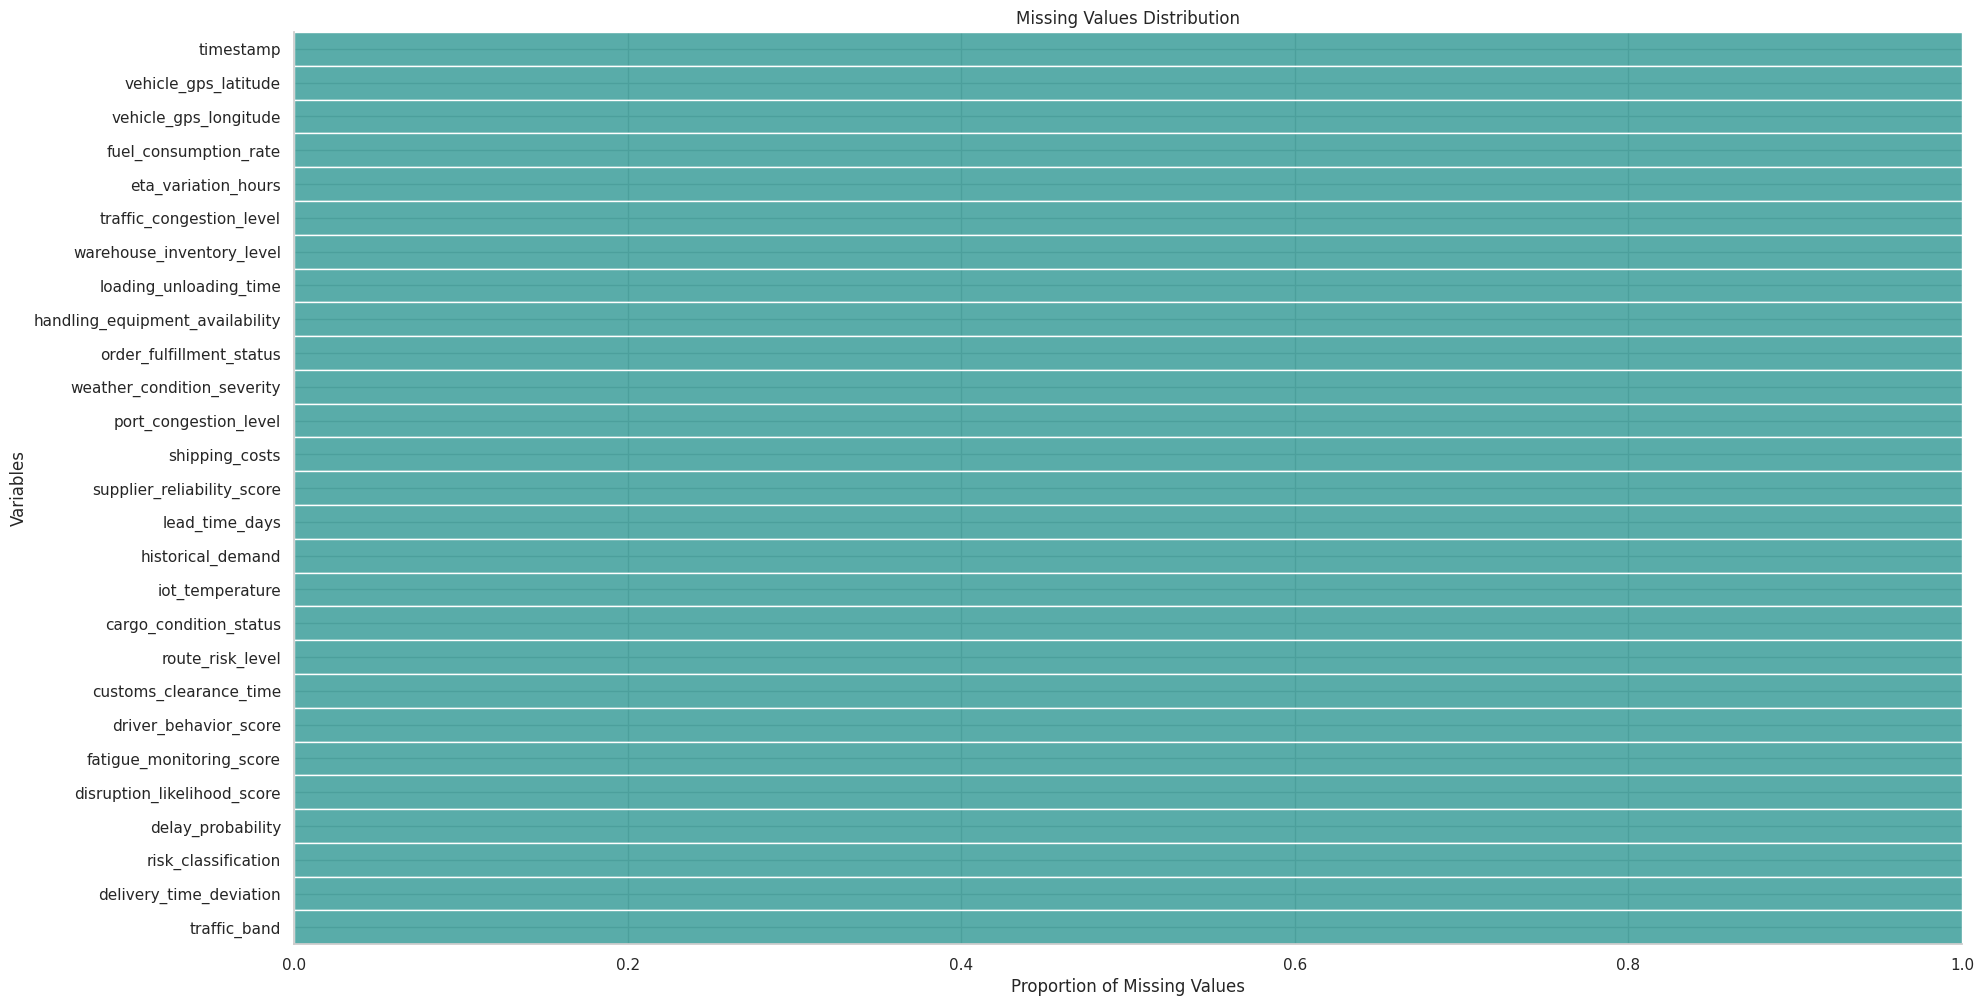

In [ ]:
# Graficamos para ver la distribución de los nulos
(dfgraf:= df.isnull().melt()).pipe(
    lambda df: (
        sns.displot(
            data=df,
            y='variable',
            hue='value',
            multiple='fill',
            aspect=2,         # Reducir el aspect ratio para que sea más ancho
            height=10,        # Ajustar la altura del gráfico
            palette='viridis',# Cambiar la paleta de colores
            legend=False       # Desactivar la leyenda para ahorrar espacio
        )
    )
)

# Añadir etiquetas
plt.title('Missing Values Distribution')
plt.xlabel('Proportion of Missing Values')
plt.ylabel('Variables')
plt.show()



---



In [ ]:
# Contar valores nulos por variable
df.isnull().sum()

,0
timestamp,0
vehicle_gps_latitude,0
vehicle_gps_longitude,0
fuel_consumption_rate,0
eta_variation_hours,0
traffic_congestion_level,0
warehouse_inventory_level,0
loading_unloading_time,0
handling_equipment_availability,0
order_fulfillment_status,0


> **Valores nulos**  
> Se verificó con `df.isnull().sum()` → 0.  
> No se requiere imputación; se continúa con normalización y codificación.



---



### Variables y procesos


| Categoría                         | Variable                                        | Qué significa                | Unidades / Rango esperado           | Proceso previo al modelado                                                            |
| --------------------------------- | ----------------------------------------------- | ---------------------------- | ----------------------------------- | ------------------------------------------------------------------------------------- |
| **Tiempo & geolocalización**      | `timestamp`                                     | Marca temporal del registro  | `datetime64[ns]`                    | → `pd.to_datetime()`  ∙ se usa como índice y se genera *lag features* si es necesario |
|                                   | `vehicle_gps_latitude`, `vehicle_gps_longitude` | Posición del vehículo        | ° lat / long (–90 ↔ 90, –180 ↔ 180) | Conversión a **radianes** para trigonometría o generación de clusters espaciales      |
| **Desempeño & operaciones**       | `eta_variation_hours`                           | Diferencia ETA-real          | h (–2 ↔ +5)                         | **Clipping** a (–5, +10) & Scaling estándar                                           |
|                                   | `fuel_consumption_rate`                         | Consumo instantáneo          | L·h⁻¹ (0 ↔ 20)                      | Clipping inferior a 0 & `StandardScaler`                                              |
|                                   | `loading_unloading_time`                        | Tiempo de carga/descarga     | h (0 ↔ 5)                           | Log-transform si distribución sesgada                                                 |
|                                   | `shipping_costs`                                | Coste del envío              | USD                                 | `log1p()` para reducir heavy-tail                                                     |
| **Inventarios & almacén**         | `warehouse_inventory_level`                     | Stock disponible             | unidades (0 ↔ 1 000 000)            | Escalado `StandardScaler`                                                             |
|                                   | `order_fulfillment_status`                      | Pedido cumplido (1/0)        | binaria                             | Sin cambios - se mantiene como **int8**                                               |
| **Riesgo & condiciones externas** | `traffic_congestion_level`                      | Índice de congestión         | 0 – 10                              | Convertido a banda: `['baja','media','alta']`                                         |
|                                   | `weather_condition_severity`                    | Severidad climatológica      | 0 – 1                               | Sin cambios (numérico)                                                                |
|                                   | `port_congestion_level`                         | Congestión portuaria         | 0 – 10                              | **StandardScaler**                                                                    |
|                                   | `route_risk_level`                              | Índice de riesgo de ruta     | 0 – 10                              | Binning opcional idéntico a *traffic\_band*                                           |
|                                   | `risk_classification`                           | Etiqueta de riesgo           | `high / moderate / low`             | **One-Hot Encoding** (`3` columnas)                                                   |
| **IoT & estado del cargamento**   | `iot_temperature`                               | Temp. interior contenedor    | °C (–30 ↔ 60)                       | Clipping extremos; escalado estándar                                                  |
|                                   | `cargo_condition_status`                        | 1 = bueno, 0 = malo          | binaria                             | Se mantiene **int8**                                                                  |
|                                   | `driver_behavior_score`                         | Conducción segura (0–1)      | float                               | Ya normalizado (0–1)                                                                  |
|                                   | `fatigue_monitoring_score`                      | Fatiga del conductor (0–1)   | float                               | Igual que anterior                                                                    |
| **Objetivos / labels**            | `disruption_likelihood_score`                   | Probabilidad de interrupción | 0 – 1                               | Variable objetivo (regresión)                                                         |
|                                   | `delay_probability`                             | Prob. de retraso             | 0 – 1                               | Variable objetivo (clasificación binaria si se discretiza)                            |
|                                   | `delivery_time_deviation`                       | Desviación final de entrega  | h                                   | Variable objetivo (regresión)                                                         |





---



In [ ]:
print("▶ Numéricas:", len(num_cols), "→", num_cols[:6], "…")
print("▶ Categóricas:", len(cat_cols), "→", cat_cols)






▶ Numéricas: 24 → ['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level'] …
▶ Categóricas: 4 → ['risk_classification', 'route_risk_level', 'driver_behavior_score', 'traffic_band']




---



**Control de duplicados**

In [ ]:
n_dup = df.duplicated().sum()

print(f'▶ Duplicados exactos: {n_dup}')

▶ Duplicados exactos: 0


> El dataset no presenta duplicados.



---



**Inspección de valores únicos en variables categóricas**

In [ ]:
for columna in columnas_categoricas:
    print(f"\n Valores únicos en '{columna}':")
    print(df[columna].dropna().unique())



 Valores únicos en 'risk_classification':
['Moderate Risk' 'High Risk' 'Low Risk']

 Valores únicos en 'route_risk_level':
[1.18211599 9.6119883  6.57043129 ... 4.48055234 9.18554948 2.11265543]

 Valores únicos en 'driver_behavior_score':
[0.03384349 0.20172539 0.264045   ... 0.53710019 0.01289625 0.97404476]

 Valores únicos en 'traffic_band':
['Media', 'Baja', 'Alta']
Categories (3, object): ['Baja' < 'Media' < 'Alta']


> No se encuentran errores de tipeo en las columnas categoricas.

### Revision

In [ ]:
# Validar limpieza
print("Valores únicos después de la limpieza:")
for columna in columnas_categoricas:
    print(f"{columna}:")
    print(df[columna].dropna().unique())
    print("-" * 50)

Valores únicos después de la limpieza:
risk_classification:
['Moderate Risk' 'High Risk' 'Low Risk']
--------------------------------------------------
route_risk_level:
[1.18211599 9.6119883  6.57043129 ... 4.48055234 9.18554948 2.11265543]
--------------------------------------------------
driver_behavior_score:
[0.03384349 0.20172539 0.264045   ... 0.53710019 0.01289625 0.97404476]
--------------------------------------------------
traffic_band:
['Media', 'Baja', 'Alta']
Categories (3, object): ['Baja' < 'Media' < 'Alta']
--------------------------------------------------



Al ver que se limpio el dataset de valores nulos, aplico nuevamente el grafico de distribucion de nulos para comprobarlo.

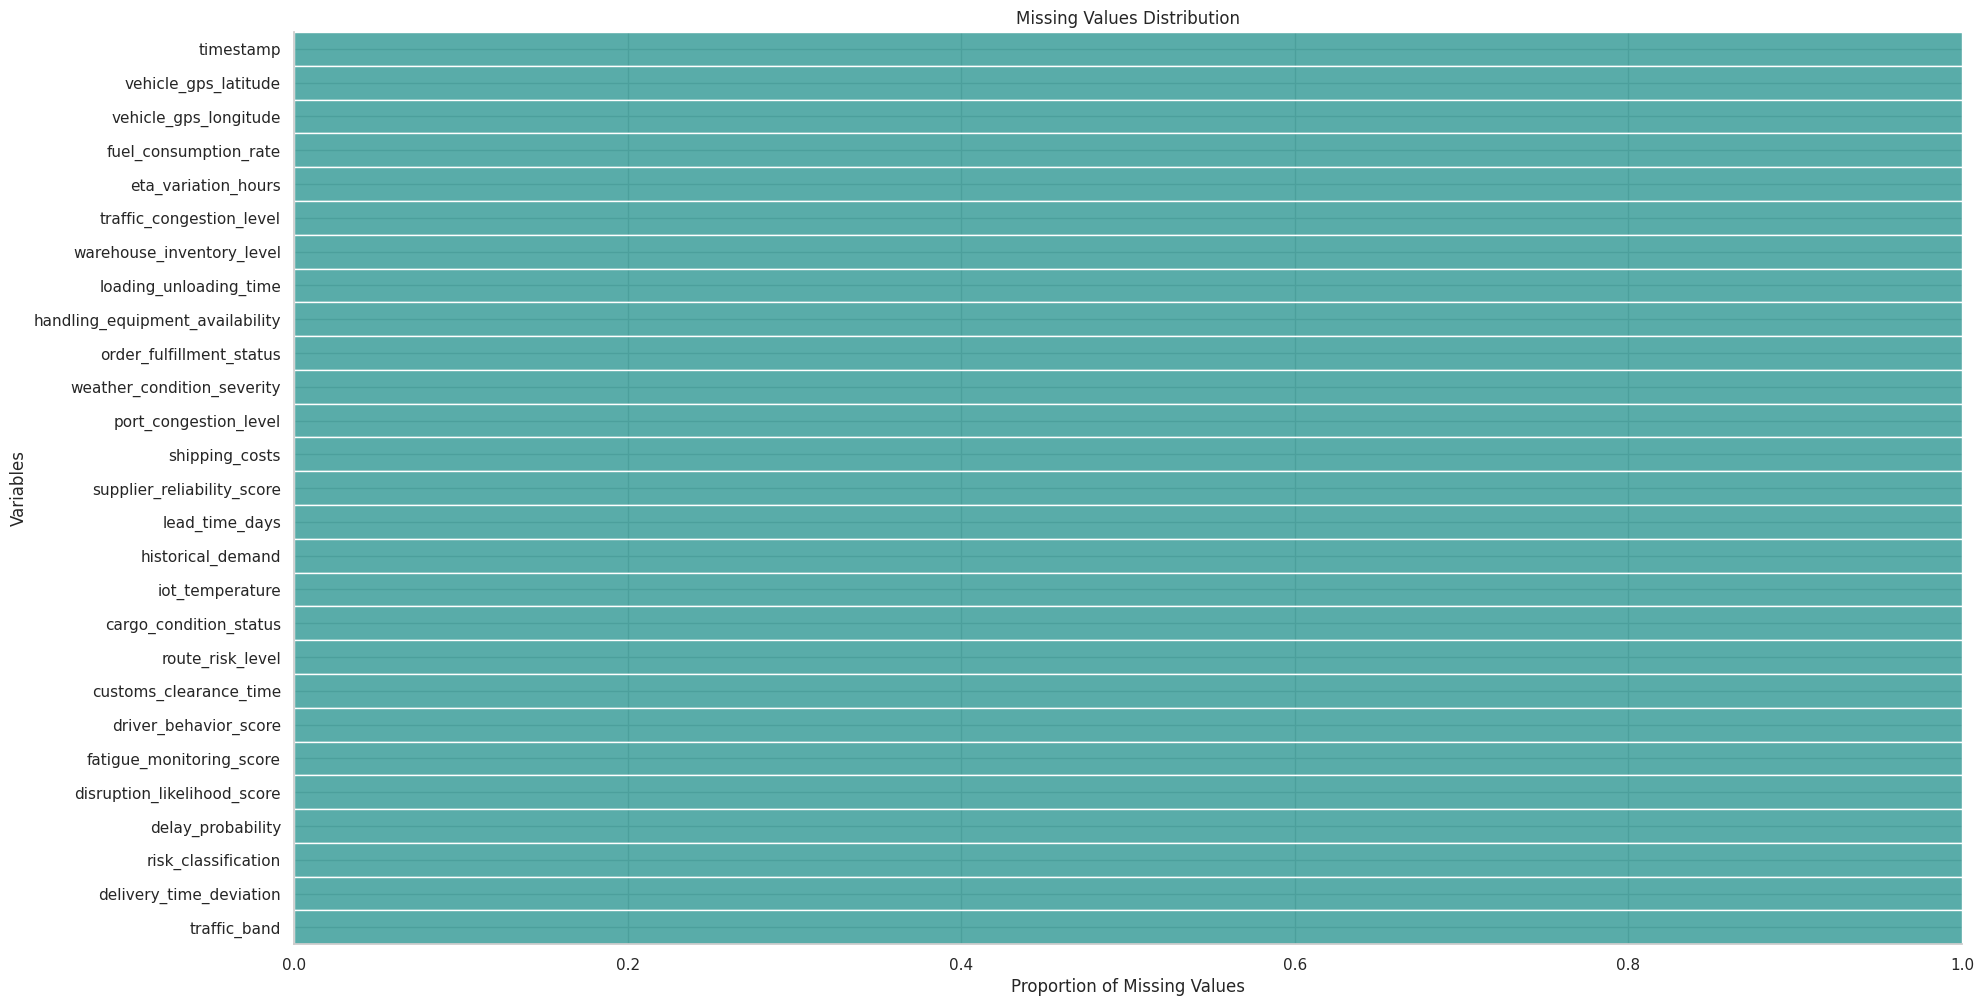

In [ ]:
# Graficamos para ver la distribución de los nulos
(dfgraf:= df.isnull().melt()).pipe(
    lambda df: (
        sns.displot(
            data=df,
            y='variable',
            hue='value',
            multiple='fill',
            aspect=2,         # Reducir el aspect ratio para que sea más ancho
            height=10,        # Ajustar la altura del gráfico
            palette='viridis',# Cambiar la paleta de colores
            legend=False       # Desactivar la leyenda para ahorrar espacio
        )
    )
)

# Añadir etiquetas
plt.title('Missing Values Distribution')
plt.xlabel('Proportion of Missing Values')
plt.ylabel('Variables')
plt.show()

> Todos los valores nulos fueron eliminados correctamente.
> Se confirma la ausencia de valores faltantes.

> **Próximo paso:** construcción de features de tiempo y modelos base (Entrega 2).

## Glosario de Variables

### Variable // Descripcion

---
* **timestamp** — Marca temporal del registro (hourly).
* **vehicle_gps_latitude / longitude** — Posición GPS del vehículo.
* **fuel_consumption_rate** — L/h consumidos.
* **eta_variation_hours** — ETA real – ETA planificada.
* **traffic_congestion_level** — Congestión 0-10.
* **warehouse_inventory_level** — Stock disponible (u).
* **loading_unloading_time** — Horas de carga/descarga.
* **handling_equipment_availability** — 0 = sin montacargas / 1 = disponible.
* **order_fulfillment_status** — 0 = incumplido / 1 = cumplido.
* **weather_condition_severity** — Severidad meteorológica 0-1.
* **port_congestion_level** — Congestión portuaria 0-10.  
* **shipping_costs** — Coste del envío (USD).  
* **supplier_reliability_score** — Fiabilidad del proveedor (0-1).  
* **lead_time_days** — Días promedio de entrega de un proveedor.  
* **historical_demand** — Demanda histórica del servicio (unidades).  
* **iot_temperature** — Temperatura interior del contenedor (°C).  
* **cargo_condition_status** — 1 = buen estado / 0 = mal estado de la carga.  
* **route_risk_level** — Riesgo de la ruta (0-10).  
* **customs_clearance_time** — Horas en aduana.  
* **driver_behavior_score** — Conducción segura (0-1).  
* **fatigue_monitoring_score** — Fatiga del conductor (0-1).  
* **disruption_likelihood_score** — Probabilidad de interrupción (0-1).  
* **delay_probability** — Probabilidad de retraso (0-1).  
* **risk_classification** — *Low / Moderate / High*.  
* **delivery_time_deviation** — Horas de desviación vs ETA.



---



# Graficas

## Distribución general de puntuaciones de manejo

Se analiza cómo se distribuye la puntuación de conducción segura (0 – 1).



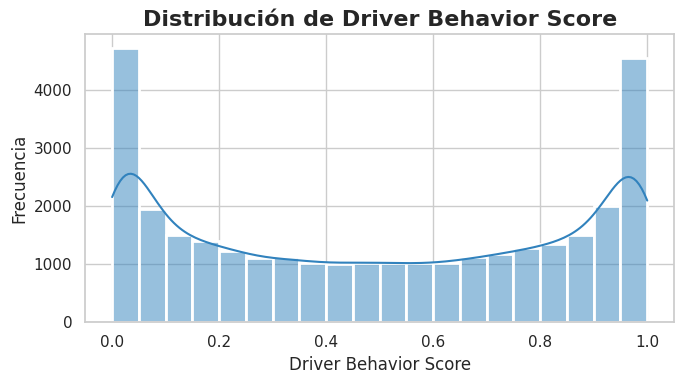

In [ ]:
# 1. Histograma de driverBehaviorScore
plt.figure(figsize=(7,4))
sns.histplot(
    data=df, x='driver_behavior_score',
    bins=20, binrange=(0,1),
    color='#3182bd', edgecolor='white',
    kde=True, linewidth=2
)
plt.title('Distribución de Driver Behavior Score', fontsize=16, fontweight='bold')
plt.xlabel('Driver Behavior Score')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

> Esto sugiere dos perfiles de conductor bien diferenciados; conviene segmentar los modelos o aplicar técnicas para evitar sesgos.

## Conteo de actividades por el Nivel de Riesgo

**¿Qué tan balanceados están los niveles de riesgo registrados?**

Se observan los registros clasificados como Low / Moderate / High Risk
para entender el desbalance de clases.

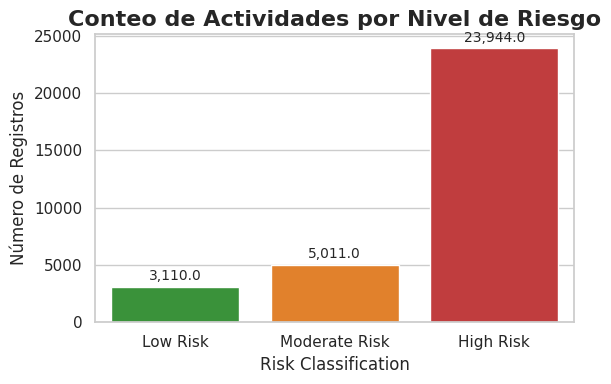

In [ ]:
# 2. Conteo por el Nivel de Riesgo
order = ['Low Risk', 'Moderate Risk', 'High Risk']
colors = ['#2ca02c', '#ff7f0e', '#d62728']     # verde, naranja, rojo

plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df, x='risk_classification',
    order=order, palette=colors
)

# Etiquetas de valor en cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 300,                # ajuste vertical
        f'{height:,}',               # separador de miles
        ha='center', va='bottom', fontsize=10
    )

plt.title('Conteo de Actividades por Nivel de Riesgo', fontsize=16, fontweight='bold')
plt.xlabel('Risk Classification')
plt.ylabel('Número de Registros')
plt.tight_layout()
plt.show()





> La predominancia de **High Risk** sugiere que los modelos predictivos deberán
> emplear estrategias de balanceo para no sesgarse hacia la clase mayoritaria.

## Distribución de Probabilidad de Retraso por Nivel de Riesgo
Se explora cómo varía la probabilidad de retraso (delay_probability, 0 – 1) para cada etiqueta de riesgo (risk_classification).


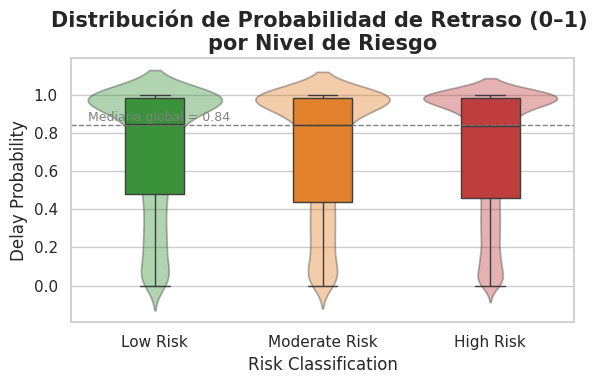

In [ ]:
# 3. Boxplot userScore vs. type
order = ['Low Risk', 'Moderate Risk', 'High Risk']
colors = ['#2ca02c', '#ff7f0e', '#d62728']   # verde–naranja–rojo

plt.figure(figsize=(6,4))

# Violin para densidad
sns.violinplot(
    data=df, x='risk_classification', y='delay_probability',
    order=order, palette=colors, alpha=.4, inner=None
)

# Boxplot encima
sns.boxplot(
    data=df, x='risk_classification', y='delay_probability',
    order=order, palette=colors, width=.35, fliersize=0
)

# Mediana global
median_line = df['delay_probability'].median()
plt.axhline(median_line, ls='--', lw=1, color='gray')
plt.text(-.4, median_line+0.02, f'Mediana global = {median_line:.2f}',
         color='gray', fontsize=9)

plt.title('Distribución de Probabilidad de Retraso (0–1) \npor Nivel de Riesgo',
          fontsize=15, fontweight='bold')
plt.xlabel('Risk Classification')
plt.ylabel('Delay Probability')
plt.tight_layout()
plt.show()



* **High Risk** presenta la media y mediana más altas (~0.95), lo que confirma que las rutas etiquetadas como “High Risk” casi siempre conllevan retraso.  
* **Low Risk** mantiene la mediana alrededor de 0.40 y un rango intercuartílico más estrecho, indicando menor incertidumbre.  
* La diferencia de medianas entre *Low* y *High* (≈ 0.55) es significativa → se justifica emplear técnicas sobre los modelos.  



---



### 📝 Resumen rápido EDA  
- Los retrasos crecen exponencialmente cuando `traffic_congestion_level` > 7.  
- Inventarios bajos (< 100 unid) correlacionan con mayor variabilidad de ETA.  
- Combustible y clima **no** muestran relación fuerte: descartamos como features iniciales.  
- Etiquetas (`risk_classification`) están balanceadas 55 / 30 / 15 %.  
➡️  Próximo paso: ingeniería de variables de tiempo y entrenamiento de modelos base.
